In [156]:
import numpy as np   
import pandas as pd   
import matplotlib.pyplot as plt   
import seaborn as sns   
from scipy import stats
import warnings
import pickle   


from os import path

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn import metrics
from sklearn import preprocessing
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split 
from sklearn.metrics import classification_report

 
 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
 

warnings.simplefilter('ignore')

pd.set_option('display.max_columns', None)


In [158]:
df_1 = pd.read_csv('UNSW-NB15_1.csv')
df_2 = pd.read_csv('UNSW-NB15_2.csv')
df_3 = pd.read_csv('UNSW-NB15_3.csv')
df_4 = pd.read_csv('UNSW-NB15_4.csv')
df_events = pd.read_csv('UNSW-NB15_LIST_EVENTS.csv')
df_features = pd.read_csv('UNSW-NB15_features.csv',encoding="ISO-8859-1")


# Reading datasets

In [160]:
df_1

,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,29,0,0.1,dns,500473.9375,621800.9375,2,2.1,0.2,0.3,0.4,0.5,66,82,0.6,0.7,0.8,0.9,1421927414,1421927414.1,0.017,0.013,0.10,0.11,0.12,0.13,0.14,0.15,0.16,0.17,3,7,1,3.1,1.1,1.2,1.3,Unnamed: 47,0.18
0,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,29,0,0,-,8.767609e+04,5.048017e+04,4,4,0,0,0,0,132,76,0,0,9.891010,10.682733,1421927414,1421927414,7.005000,7.564333,0.000000,0.000000,0.000000,0,0,0,0,0,2,4,2,3,1,1,2,NaN,0
1,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,29,0,0,dns,5.218945e+05,6.362824e+05,2,2,0,0,0,0,73,89,0,0,0.000000,0.000000,1421927414,1421927414,0.017000,0.013000,0.000000,0.000000,0.000000,0,0,0,0,0,12,8,1,2,2,1,1,NaN,0
2,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,29,0,0,dns,4.367246e+05,5.425972e+05,2,2,0,0,0,0,66,82,0,0,0.000000,0.000000,1421927414,1421927414,0.043000,0.014000,0.000000,0.000000,0.000000,0,0,0,0,0,6,9,1,1,1,1,1,NaN,0
3,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,29,0,0,dns,4.995722e+05,6.090676e+05,2,2,0,0,0,0,73,89,0,0,0.000000,0.000000,1421927414,1421927414,0.005000,0.003000,0.000000,0.000000,0.000000,0,0,0,0,0,7,9,1,1,1,1,1,NaN,0
4,59.166.0.0,32119,149.171.126.9,111,udp,CON,0.078339,568,312,31,29,0,0,-,4.350323e+04,2.389614e+04,4,4,0,0,0,0,142,78,0,0,29.682221,34.370340,1421927414,1421927414,21.003000,24.315000,0.000000,0.000000,0.000000,0,0,0,0,0,2,4,2,3,1,1,2,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699995,59.166.0.8,12520,149.171.126.6,31010,tcp,FIN,0.020383,320,1874,31,29,1,2,-,1.047932e+05,6.436736e+05,6,8,255,255,3208686479,3225486168,53,234,0,0,212.810729,3.079195,1421955842,1421955842,4.007400,2.027429,0.006386,0.006189,0.000197,0,0,0,0,0,8,20,7,5,1,1,4,NaN,0
699996,59.166.0.0,18895,149.171.126.9,80,tcp,FIN,1.402957,19410,1087890,31,29,2,370,http,1.103783e+05,6.195098e+06,364,746,255,255,283296697,2429736754,53,1458,1,3924,203.808900,114.173588,1421955841,1421955842,3.864028,1.882421,0.000712,0.000550,0.000162,0,0,4,0,0,1,1,2,7,2,2,2,NaN,0
699997,59.166.0.0,30103,149.171.126.5,5190,tcp,FIN,0.007108,2158,2464,31,29,6,6,-,2.328644e+06,2.658413e+06,24,24,255,255,703293844,2848960529,90,103,0,0,17.627831,0.432619,1421955842,1421955842,0.274261,0.285478,0.000657,0.000532,0.000125,0,0,0,0,0,13,13,6,7,2,1,2,NaN,0
699998,59.166.0.6,30388,149.171.126.5,111,udp,CON,0.004435,568,304,31,29,0,0,-,7.684329e+05,4.112740e+05,4,4,0,0,0,0,142,76,0,0,1.638604,1.390643,1421955842,1421955842,1.165667,0.987333,0.000000,0.000000,0.000000,0,0,0,0,0,10,13,6,5,1,1,3,NaN,0


In [161]:
df_2

,59.166.0.0,6055,149.171.126.5,54145,tcp,FIN,0.072974,4238,60788,31,29,7,30,-,458245.4375,6571546.5,72,72.1,255,255.1,1003293149,1003585034,59,844,0,0.1,62.04531,61.899776,1421955842,1421955842.1,1.02269,0.997042,0.002317,0.002173,0.000144,0.2,0.3,0.4,0.5,0.6,13,13.1,6,7.1,1,1.1,2,Unnamed: 47,0.7
0,59.166.0.0,7832,149.171.126.3,5607,tcp,FIN,0.144951,5174,91072,31,29,7,39,-,2.824127e+05,4.971776e+06,90,92,255,255,3152877672,1047439924,57,990,0,0,98.166675,97.062913,1421955842,1421955842,1.624562,1.587374,0.000665,0.000497,0.000168,0,0,0.0,0.0,0,13,13,6,7,1,1,2,NaN,0
1,59.166.0.8,11397,149.171.126.6,21,tcp,FIN,0.116107,2934,3742,31,29,11,15,ftp,1.982998e+05,2.530769e+05,52,54,255,255,3208685093,3215278370,56,69,0,0,194.564141,4.796288,1421955842,1421955842,2.314660,2.149906,0.002342,0.002151,0.000191,0,0,0.0,1.0,1,1,2,7,5,1,1,4,NaN,0
2,59.166.0.0,3804,149.171.126.3,53,udp,CON,0.000986,146,178,31,29,0,0,-,5.922921e+05,7.221095e+05,2,2,0,0,0,0,73,89,0,0,0.000000,0.000000,1421955842,1421955842,0.011000,0.009000,0.000000,0.000000,0.000000,0,0,0.0,0.0,0,13,13,6,7,1,1,2,NaN,0
3,59.166.0.8,14339,149.171.126.6,14724,tcp,FIN,0.038480,8928,320,31,29,4,1,-,1.723701e+06,5.550936e+04,14,6,255,255,1063301791,1113098865,638,53,0,0,245.278645,11.454426,1421955842,1421955842,2.960000,6.054000,0.008268,0.008075,0.000193,0,0,0.0,0.0,0,8,20,7,5,1,1,4,NaN,0
4,59.166.0.8,39094,149.171.126.3,53,udp,CON,0.001026,130,162,31,29,0,0,-,5.068226e+05,6.315789e+05,2,2,0,0,0,0,65,81,0,0,0.000000,0.000000,1421955842,1421955842,0.010000,0.002000,0.000000,0.000000,0.000000,0,0,0.0,0.0,0,8,13,6,5,1,1,1,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699995,149.171.126.18,1043,175.45.176.3,53,udp,INT,0.000005,264,0,60,0,0,0,dns,2.112000e+08,0.000000e+00,2,0,0,0,0,0,132,0,0,0,0.000000,0.000000,1424231129,1424231129,0.005000,0.000000,0.000000,0.000000,0.000000,0,0,NaN,NaN,,19,19,19,19,19,19,19,NaN,0
699996,149.171.126.18,1043,175.45.176.3,53,udp,INT,0.000005,264,0,60,0,0,0,dns,2.112000e+08,0.000000e+00,2,0,0,0,0,0,132,0,0,0,0.000000,0.000000,1424231129,1424231129,0.005000,0.000000,0.000000,0.000000,0.000000,0,0,NaN,NaN,,19,19,19,19,19,19,19,NaN,0
699997,149.171.126.18,1043,175.45.176.3,53,udp,INT,0.000005,264,0,60,0,0,0,dns,2.112000e+08,0.000000e+00,2,0,0,0,0,0,132,0,0,0,0.000000,0.000000,1424231129,1424231129,0.005000,0.000000,0.000000,0.000000,0.000000,0,0,NaN,NaN,,19,19,19,19,19,19,19,NaN,0
699998,149.171.126.18,1043,175.45.176.3,53,udp,INT,0.000005,264,0,60,0,0,0,dns,2.112000e+08,0.000000e+00,2,0,0,0,0,0,132,0,0,0,0.000000,0.000000,1424231129,1424231129,0.005000,0.000000,0.000000,0.000000,0.000000,0,0,NaN,NaN,,19,19,19,19,19,19,19,NaN,0


In [162]:
df_3

,59.166.0.1,18247,149.171.126.4,7662,tcp,FIN,0.119596,4550,68342,31,29,7,33,-,300478.2813,4514398.5,78,80,255,255.1,1818376620,1818657356,58,854,0,0.1,87.137592,85.643619,1424231129,1424231129.1,1.549156,1.50719,0.000644,0.000521,0.000123,0.2,0.3,Unnamed: 37,Unnamed: 38,,6,2,2.1,5,1,1.1,2.2,Unnamed: 47,0.4
0,59.166.0.3,54771,149.171.126.2,27709,tcp,FIN,0.650574,8928,320,31,29,4,1,ftp-data,1.019530e+05,3.283254e+03,14,6,255,255,4075447467,3777413974,638,53,0,0,4045.664812,162.187656,1424231129,1424231129,50.044153,129.990797,0.000616,0.000495,0.000121,0,0,NaN,NaN,,3,5,2,4,1,1,4,NaN,0
1,59.166.0.8,13289,149.171.126.9,5190,tcp,FIN,0.007980,2158,2464,31,29,6,6,-,2.074185e+06,2.367920e+06,24,24,255,255,1638377249,1638673555,90,103,0,0,23.013883,0.487342,1424231129,1424231129,0.347545,0.322913,0.000668,0.000544,0.000124,0,0,NaN,NaN,,3,5,1,1,1,1,3,NaN,0
2,149.171.126.18,1043,175.45.176.3,53,udp,INT,0.000005,264,0,60,0,0,0,dns,2.112000e+08,0.000000e+00,2,0,0,0,0,0,132,0,0,0,0.000000,0.000000,1424231129,1424231129,0.005000,0.000000,0.000000,0.000000,0.000000,0,0,NaN,NaN,,19,19,19,19,19,19,19,NaN,0
3,149.171.126.18,1043,175.45.176.3,53,udp,INT,0.000005,264,0,60,0,0,0,dns,2.112000e+08,0.000000e+00,2,0,0,0,0,0,132,0,0,0,0.000000,0.000000,1424231129,1424231129,0.005000,0.000000,0.000000,0.000000,0.000000,0,0,NaN,NaN,,19,19,19,19,19,19,19,NaN,0
4,59.166.0.3,10275,149.171.126.0,25,tcp,FIN,0.486578,37462,3380,31,29,18,8,smtp,6.040882e+05,5.425646e+04,52,42,255,255,1518379503,3670369209,720,80,0,0,768.061343,24.935787,1424231128,1424231129,9.533961,11.645000,0.016012,0.009132,0.006880,0,0,NaN,NaN,,3,2,3,4,2,1,2,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699995,59.166.0.0,2111,149.171.126.5,53,udp,CON,0.001035,146,178,31,29,0,0,dns,5.642512e+05,6.879228e+05,2,2,0,0,0,0,73,89,0,0,0.000000,0.000000,1424250009,1424250009,0.009000,0.002000,0.000000,0.000000,0.000000,0,0,NaN,NaN,,1,3,4,3,1,1,4,NaN,0
699996,59.166.0.5,49044,149.171.126.3,30639,tcp,FIN,0.220630,424,8824,31,29,1,4,ftp-data,1.345239e+04,2.933055e+05,8,12,255,255,3391721010,3572288763,53,735,0,0,2618.456705,1672.549935,1424250009,1424250009,31.470857,20.014273,0.000604,0.000470,0.000134,0,0,NaN,NaN,,3,3,3,3,1,1,4,NaN,0
699997,59.166.0.6,37717,149.171.126.7,35667,tcp,FIN,0.031576,2646,25564,31,29,7,15,-,6.544211e+05,6.329618e+06,42,44,255,255,3867523398,3891033419,63,581,0,0,0.000000,49.290003,1424250009,1424250009,0.761463,0.722442,0.000630,0.000509,0.000121,0,0,NaN,NaN,,7,6,7,4,1,1,3,NaN,0
699998,59.166.0.2,1768,149.171.126.7,64122,tcp,FIN,0.096835,4862,82782,31,29,7,36,-,3.969639e+05,6.759540e+06,84,86,255,255,3991718033,4022611032,58,963,0,0,72.528230,70.686165,1424250009,1424250009,1.176768,1.132871,0.000677,0.000539,0.000138,0,0,NaN,NaN,,6,6,7,7,1,1,2,NaN,0


In [163]:
df_4

,59.166.0.9,7045,149.171.126.7,25,tcp,FIN,0.201886,37552,3380,31,29,18,8,smtp,1459437.5,130766.8672,52,42,255,255.1,1422136554,3572668484,722,80,0,0.1,456.043567,15.530109,1424250009,1424250009.1,3.943843,4.912488,0.00059,0.000473,0.000117,0.2,0.3,Unnamed: 37,Unnamed: 38,,2,2.1,7,4,1,1.1,3,Unnamed: 47,0.4
0,59.166.0.9,9685,149.171.126.2,80,tcp,FIN,5.864748,19410,1087890,31,29,2,370,http,2.640454e+04,1.481983e+06,364,746,255,255,389619597,394688654,53,1458,1,0,1031.366423,690.219581,1424250003,1424250009,16.155447,7.871279,0.000771,0.000638,0.000133,0,0,1.0,NaN,,3,1,4,4,1,1,1,NaN,0
1,59.166.0.2,1421,149.171.126.4,53,udp,CON,0.001391,146,178,31,29,0,0,dns,4.198418e+05,5.118620e+05,2,2,0,0,0,0,73,89,0,0,0.000000,0.000000,1424250009,1424250009,0.009000,0.002000,0.000000,0.000000,0.000000,0,0,NaN,NaN,,3,5,2,7,1,1,4,NaN,0
2,59.166.0.2,21553,149.171.126.2,25,tcp,FIN,0.053948,37812,3380,31,29,19,8,smtp,5.503374e+06,4.893601e+05,54,42,255,255,4047523379,1903327524,700,80,0,0,65.909688,3.155258,1424250009,1424250009,1.011547,1.302561,0.000674,0.000540,0.000134,0,0,NaN,NaN,,1,1,4,7,1,1,3,NaN,0
3,59.166.0.8,45212,149.171.126.4,53,udp,CON,0.000953,146,178,31,29,0,0,dns,6.128017e+05,7.471144e+05,2,2,0,0,0,0,73,89,0,0,0.000000,0.000000,1424250009,1424250009,0.009000,0.004000,0.000000,0.000000,0.000000,0,0,NaN,NaN,,2,5,2,1,1,1,2,NaN,0
4,59.166.0.0,59922,149.171.126.8,6881,tcp,FIN,8.633186,25056,1094788,31,29,38,390,-,2.316642e+04,1.013311e+06,446,858,255,255,497111133,526810925,56,1276,0,0,7751.702640,5572.343447,1424250000,1424250009,19.443407,10.084887,0.000654,0.000516,0.000138,0,0,NaN,NaN,,9,7,2,3,2,1,6,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440038,59.166.0.5,33094,149.171.126.7,43433,tcp,FIN,0.087306,320,1828,31,29,1,2,ftp-data,2.446567e+04,1.466108e+05,6,8,255,255,4035116044,222196311,53,229,0,0,1221.136547,30.096029,1424262068,1424262069,17.394400,12.405143,0.000608,0.000468,0.000140,0,0,NaN,NaN,,1,2,3,3,1,1,3,NaN,0
440039,59.166.0.7,20848,149.171.126.4,21,tcp,CON,0.365058,456,346,31,29,2,2,ftp,8.743816e+03,6.333240e+03,8,6,255,255,1529727621,185369967,57,58,0,0,3961.093354,129.038367,1424262068,1424262069,51.976999,72.915602,0.000609,0.000477,0.000132,0,0,NaN,2.0,2,2,2,2,2,2,2,2,NaN,0
440040,59.166.0.3,21511,149.171.126.9,21,tcp,CON,6.335154,1802,2088,31,29,7,9,ftp,2.204840e+03,2.549583e+03,32,30,255,255,497208793,889904111,56,70,0,0,13233.728560,379.052750,1424262062,1424262069,204.359814,214.372375,0.000617,0.000485,0.000132,0,0,NaN,2.0,2,2,2,4,2,2,2,2,NaN,0
440041,59.166.0.9,35433,149.171.126.0,80,tcp,CON,2.200934,3498,166054,31,29,2,57,http,1.249651e+04,5.983751e+05,58,116,255,255,1289728069,3436097151,60,1432,1,79745,2868.893137,1951.035944,1424262067,1424262069,38.609700,19.133826,0.000680,0.000541,0.000139,0,0,2.0,NaN,,1,1,2,4,2,2,2,NaN,0


In [164]:
df_events

,Attack category,Attack subcategory,Number of events
0,normal,NaN,2218761
1,Fuzzers,FTP,558
2,Fuzzers,HTTP,1497
3,Fuzzers,RIP,3550
4,Fuzzers,SMB,5245
...,...,...,...
203,Shellcode,Decoders,18
204,Shellcode,Multiple OS,10
205,Shellcode,Solaris,12
206,Worms,,174


In [165]:
df_features

,No.,Name,Type,Description
0,1,srcip,nominal,Source IP address
1,2,sport,integer,Source port number
2,3,dstip,nominal,Destination IP address
3,4,dsport,integer,Destination port number
4,5,proto,nominal,Transaction protocol
5,6,state,nominal,Indicates to the state and its dependent proto...
6,7,dur,Float,Record total duration
7,8,sbytes,Integer,Source to destination transaction bytes
8,9,dbytes,Integer,Destination to source transaction bytes
9,10,sttl,Integer,Source to destination time to live value


In [166]:
features = df_features.Name.values
features

array(['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur',
       'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service',
       'Sload', 'Dload', 'Spkts', 'Dpkts', 'swin', 'dwin', 'stcpb',
       'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len',
       'Sjit', 'Djit', 'Stime', 'Ltime', 'Sintpkt', 'Dintpkt', 'tcprtt',
       'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl',
       'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src',
       'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ ltm', 'ct_src_dport_ltm',
       'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'Label'],
      dtype=object)

# Data Preprocessing

In [167]:
df_1.columns = features
df_1


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,Sload,Dload,Spkts,Dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,Sjit,Djit,Stime,Ltime,Sintpkt,Dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,29,0,0,-,8.767609e+04,5.048017e+04,4,4,0,0,0,0,132,76,0,0,9.891010,10.682733,1421927414,1421927414,7.005000,7.564333,0.000000,0.000000,0.000000,0,0,0,0,0,2,4,2,3,1,1,2,NaN,0
1,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,29,0,0,dns,5.218945e+05,6.362824e+05,2,2,0,0,0,0,73,89,0,0,0.000000,0.000000,1421927414,1421927414,0.017000,0.013000,0.000000,0.000000,0.000000,0,0,0,0,0,12,8,1,2,2,1,1,NaN,0
2,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,29,0,0,dns,4.367246e+05,5.425972e+05,2,2,0,0,0,0,66,82,0,0,0.000000,0.000000,1421927414,1421927414,0.043000,0.014000,0.000000,0.000000,0.000000,0,0,0,0,0,6,9,1,1,1,1,1,NaN,0
3,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,29,0,0,dns,4.995722e+05,6.090676e+05,2,2,0,0,0,0,73,89,0,0,0.000000,0.000000,1421927414,1421927414,0.005000,0.003000,0.000000,0.000000,0.000000,0,0,0,0,0,7,9,1,1,1,1,1,NaN,0
4,59.166.0.0,32119,149.171.126.9,111,udp,CON,0.078339,568,312,31,29,0,0,-,4.350323e+04,2.389614e+04,4,4,0,0,0,0,142,78,0,0,29.682221,34.370340,1421927414,1421927414,21.003000,24.315000,0.000000,0.000000,0.000000,0,0,0,0,0,2,4,2,3,1,1,2,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699995,59.166.0.8,12520,149.171.126.6,31010,tcp,FIN,0.020383,320,1874,31,29,1,2,-,1.047932e+05,6.436736e+05,6,8,255,255,3208686479,3225486168,53,234,0,0,212.810729,3.079195,1421955842,1421955842,4.007400,2.027429,0.006386,0.006189,0.000197,0,0,0,0,0,8,20,7,5,1,1,4,NaN,0
699996,59.166.0.0,18895,149.171.126.9,80,tcp,FIN,1.402957,19410,1087890,31,29,2,370,http,1.103783e+05,6.195098e+06,364,746,255,255,283296697,2429736754,53,1458,1,3924,203.808900,114.173588,1421955841,1421955842,3.864028,1.882421,0.000712,0.000550,0.000162,0,0,4,0,0,1,1,2,7,2,2,2,NaN,0
699997,59.166.0.0,30103,149.171.126.5,5190,tcp,FIN,0.007108,2158,2464,31,29,6,6,-,2.328644e+06,2.658413e+06,24,24,255,255,703293844,2848960529,90,103,0,0,17.627831,0.432619,1421955842,1421955842,0.274261,0.285478,0.000657,0.000532,0.000125,0,0,0,0,0,13,13,6,7,2,1,2,NaN,0
699998,59.166.0.6,30388,149.171.126.5,111,udp,CON,0.004435,568,304,31,29,0,0,-,7.684329e+05,4.112740e+05,4,4,0,0,0,0,142,76,0,0,1.638604,1.390643,1421955842,1421955842,1.165667,0.987333,0.000000,0.000000,0.000000,0,0,0,0,0,10,13,6,5,1,1,3,NaN,0


In [168]:
df_2.columns = features
df_2

,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,Sload,Dload,Spkts,Dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,Sjit,Djit,Stime,Ltime,Sintpkt,Dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.0,7832,149.171.126.3,5607,tcp,FIN,0.144951,5174,91072,31,29,7,39,-,2.824127e+05,4.971776e+06,90,92,255,255,3152877672,1047439924,57,990,0,0,98.166675,97.062913,1421955842,1421955842,1.624562,1.587374,0.000665,0.000497,0.000168,0,0,0.0,0.0,0,13,13,6,7,1,1,2,NaN,0
1,59.166.0.8,11397,149.171.126.6,21,tcp,FIN,0.116107,2934,3742,31,29,11,15,ftp,1.982998e+05,2.530769e+05,52,54,255,255,3208685093,3215278370,56,69,0,0,194.564141,4.796288,1421955842,1421955842,2.314660,2.149906,0.002342,0.002151,0.000191,0,0,0.0,1.0,1,1,2,7,5,1,1,4,NaN,0
2,59.166.0.0,3804,149.171.126.3,53,udp,CON,0.000986,146,178,31,29,0,0,-,5.922921e+05,7.221095e+05,2,2,0,0,0,0,73,89,0,0,0.000000,0.000000,1421955842,1421955842,0.011000,0.009000,0.000000,0.000000,0.000000,0,0,0.0,0.0,0,13,13,6,7,1,1,2,NaN,0
3,59.166.0.8,14339,149.171.126.6,14724,tcp,FIN,0.038480,8928,320,31,29,4,1,-,1.723701e+06,5.550936e+04,14,6,255,255,1063301791,1113098865,638,53,0,0,245.278645,11.454426,1421955842,1421955842,2.960000,6.054000,0.008268,0.008075,0.000193,0,0,0.0,0.0,0,8,20,7,5,1,1,4,NaN,0
4,59.166.0.8,39094,149.171.126.3,53,udp,CON,0.001026,130,162,31,29,0,0,-,5.068226e+05,6.315789e+05,2,2,0,0,0,0,65,81,0,0,0.000000,0.000000,1421955842,1421955842,0.010000,0.002000,0.000000,0.000000,0.000000,0,0,0.0,0.0,0,8,13,6,5,1,1,1,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699995,149.171.126.18,1043,175.45.176.3,53,udp,INT,0.000005,264,0,60,0,0,0,dns,2.112000e+08,0.000000e+00,2,0,0,0,0,0,132,0,0,0,0.000000,0.000000,1424231129,1424231129,0.005000,0.000000,0.000000,0.000000,0.000000,0,0,NaN,NaN,,19,19,19,19,19,19,19,NaN,0
699996,149.171.126.18,1043,175.45.176.3,53,udp,INT,0.000005,264,0,60,0,0,0,dns,2.112000e+08,0.000000e+00,2,0,0,0,0,0,132,0,0,0,0.000000,0.000000,1424231129,1424231129,0.005000,0.000000,0.000000,0.000000,0.000000,0,0,NaN,NaN,,19,19,19,19,19,19,19,NaN,0
699997,149.171.126.18,1043,175.45.176.3,53,udp,INT,0.000005,264,0,60,0,0,0,dns,2.112000e+08,0.000000e+00,2,0,0,0,0,0,132,0,0,0,0.000000,0.000000,1424231129,1424231129,0.005000,0.000000,0.000000,0.000000,0.000000,0,0,NaN,NaN,,19,19,19,19,19,19,19,NaN,0
699998,149.171.126.18,1043,175.45.176.3,53,udp,INT,0.000005,264,0,60,0,0,0,dns,2.112000e+08,0.000000e+00,2,0,0,0,0,0,132,0,0,0,0.000000,0.000000,1424231129,1424231129,0.005000,0.000000,0.000000,0.000000,0.000000,0,0,NaN,NaN,,19,19,19,19,19,19,19,NaN,0


In [169]:
df_3.columns = features
df_3

,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,Sload,Dload,Spkts,Dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,Sjit,Djit,Stime,Ltime,Sintpkt,Dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.3,54771,149.171.126.2,27709,tcp,FIN,0.650574,8928,320,31,29,4,1,ftp-data,1.019530e+05,3.283254e+03,14,6,255,255,4075447467,3777413974,638,53,0,0,4045.664812,162.187656,1424231129,1424231129,50.044153,129.990797,0.000616,0.000495,0.000121,0,0,NaN,NaN,,3,5,2,4,1,1,4,NaN,0
1,59.166.0.8,13289,149.171.126.9,5190,tcp,FIN,0.007980,2158,2464,31,29,6,6,-,2.074185e+06,2.367920e+06,24,24,255,255,1638377249,1638673555,90,103,0,0,23.013883,0.487342,1424231129,1424231129,0.347545,0.322913,0.000668,0.000544,0.000124,0,0,NaN,NaN,,3,5,1,1,1,1,3,NaN,0
2,149.171.126.18,1043,175.45.176.3,53,udp,INT,0.000005,264,0,60,0,0,0,dns,2.112000e+08,0.000000e+00,2,0,0,0,0,0,132,0,0,0,0.000000,0.000000,1424231129,1424231129,0.005000,0.000000,0.000000,0.000000,0.000000,0,0,NaN,NaN,,19,19,19,19,19,19,19,NaN,0
3,149.171.126.18,1043,175.45.176.3,53,udp,INT,0.000005,264,0,60,0,0,0,dns,2.112000e+08,0.000000e+00,2,0,0,0,0,0,132,0,0,0,0.000000,0.000000,1424231129,1424231129,0.005000,0.000000,0.000000,0.000000,0.000000,0,0,NaN,NaN,,19,19,19,19,19,19,19,NaN,0
4,59.166.0.3,10275,149.171.126.0,25,tcp,FIN,0.486578,37462,3380,31,29,18,8,smtp,6.040882e+05,5.425646e+04,52,42,255,255,1518379503,3670369209,720,80,0,0,768.061343,24.935787,1424231128,1424231129,9.533961,11.645000,0.016012,0.009132,0.006880,0,0,NaN,NaN,,3,2,3,4,2,1,2,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699995,59.166.0.0,2111,149.171.126.5,53,udp,CON,0.001035,146,178,31,29,0,0,dns,5.642512e+05,6.879228e+05,2,2,0,0,0,0,73,89,0,0,0.000000,0.000000,1424250009,1424250009,0.009000,0.002000,0.000000,0.000000,0.000000,0,0,NaN,NaN,,1,3,4,3,1,1,4,NaN,0
699996,59.166.0.5,49044,149.171.126.3,30639,tcp,FIN,0.220630,424,8824,31,29,1,4,ftp-data,1.345239e+04,2.933055e+05,8,12,255,255,3391721010,3572288763,53,735,0,0,2618.456705,1672.549935,1424250009,1424250009,31.470857,20.014273,0.000604,0.000470,0.000134,0,0,NaN,NaN,,3,3,3,3,1,1,4,NaN,0
699997,59.166.0.6,37717,149.171.126.7,35667,tcp,FIN,0.031576,2646,25564,31,29,7,15,-,6.544211e+05,6.329618e+06,42,44,255,255,3867523398,3891033419,63,581,0,0,0.000000,49.290003,1424250009,1424250009,0.761463,0.722442,0.000630,0.000509,0.000121,0,0,NaN,NaN,,7,6,7,4,1,1,3,NaN,0
699998,59.166.0.2,1768,149.171.126.7,64122,tcp,FIN,0.096835,4862,82782,31,29,7,36,-,3.969639e+05,6.759540e+06,84,86,255,255,3991718033,4022611032,58,963,0,0,72.528230,70.686165,1424250009,1424250009,1.176768,1.132871,0.000677,0.000539,0.000138,0,0,NaN,NaN,,6,6,7,7,1,1,2,NaN,0


In [170]:
df_4.columns = features
df_4


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,Sload,Dload,Spkts,Dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,Sjit,Djit,Stime,Ltime,Sintpkt,Dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.9,9685,149.171.126.2,80,tcp,FIN,5.864748,19410,1087890,31,29,2,370,http,2.640454e+04,1.481983e+06,364,746,255,255,389619597,394688654,53,1458,1,0,1031.366423,690.219581,1424250003,1424250009,16.155447,7.871279,0.000771,0.000638,0.000133,0,0,1.0,NaN,,3,1,4,4,1,1,1,NaN,0
1,59.166.0.2,1421,149.171.126.4,53,udp,CON,0.001391,146,178,31,29,0,0,dns,4.198418e+05,5.118620e+05,2,2,0,0,0,0,73,89,0,0,0.000000,0.000000,1424250009,1424250009,0.009000,0.002000,0.000000,0.000000,0.000000,0,0,NaN,NaN,,3,5,2,7,1,1,4,NaN,0
2,59.166.0.2,21553,149.171.126.2,25,tcp,FIN,0.053948,37812,3380,31,29,19,8,smtp,5.503374e+06,4.893601e+05,54,42,255,255,4047523379,1903327524,700,80,0,0,65.909688,3.155258,1424250009,1424250009,1.011547,1.302561,0.000674,0.000540,0.000134,0,0,NaN,NaN,,1,1,4,7,1,1,3,NaN,0
3,59.166.0.8,45212,149.171.126.4,53,udp,CON,0.000953,146,178,31,29,0,0,dns,6.128017e+05,7.471144e+05,2,2,0,0,0,0,73,89,0,0,0.000000,0.000000,1424250009,1424250009,0.009000,0.004000,0.000000,0.000000,0.000000,0,0,NaN,NaN,,2,5,2,1,1,1,2,NaN,0
4,59.166.0.0,59922,149.171.126.8,6881,tcp,FIN,8.633186,25056,1094788,31,29,38,390,-,2.316642e+04,1.013311e+06,446,858,255,255,497111133,526810925,56,1276,0,0,7751.702640,5572.343447,1424250000,1424250009,19.443407,10.084887,0.000654,0.000516,0.000138,0,0,NaN,NaN,,9,7,2,3,2,1,6,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
440038,59.166.0.5,33094,149.171.126.7,43433,tcp,FIN,0.087306,320,1828,31,29,1,2,ftp-data,2.446567e+04,1.466108e+05,6,8,255,255,4035116044,222196311,53,229,0,0,1221.136547,30.096029,1424262068,1424262069,17.394400,12.405143,0.000608,0.000468,0.000140,0,0,NaN,NaN,,1,2,3,3,1,1,3,NaN,0
440039,59.166.0.7,20848,149.171.126.4,21,tcp,CON,0.365058,456,346,31,29,2,2,ftp,8.743816e+03,6.333240e+03,8,6,255,255,1529727621,185369967,57,58,0,0,3961.093354,129.038367,1424262068,1424262069,51.976999,72.915602,0.000609,0.000477,0.000132,0,0,NaN,2.0,2,2,2,2,2,2,2,2,NaN,0
440040,59.166.0.3,21511,149.171.126.9,21,tcp,CON,6.335154,1802,2088,31,29,7,9,ftp,2.204840e+03,2.549583e+03,32,30,255,255,497208793,889904111,56,70,0,0,13233.728560,379.052750,1424262062,1424262069,204.359814,214.372375,0.000617,0.000485,0.000132,0,0,NaN,2.0,2,2,2,4,2,2,2,2,NaN,0
440041,59.166.0.9,35433,149.171.126.0,80,tcp,CON,2.200934,3498,166054,31,29,2,57,http,1.249651e+04,5.983751e+05,58,116,255,255,1289728069,3436097151,60,1432,1,79745,2868.893137,1951.035944,1424262067,1424262069,38.609700,19.133826,0.000680,0.000541,0.000139,0,0,2.0,NaN,,1,1,2,4,2,2,2,NaN,0


In [ ]:
df_merged = pd.concat([df_1,df_2,df_3,df_4]).reset_index(drop=True)
df_merged

In [173]:
 # df_merged.to_csv("data_merged.csv",index=False)

In [174]:
df_merged[df_merged['service']=='-']

,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,Sload,Dload,Spkts,Dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,Sjit,Djit,Stime,Ltime,Sintpkt,Dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,29,0,0,-,87676.085940,5.048017e+04,4,4,0,0,0,0,132,76,0,0,9.891010,10.682733,1421927414,1421927414,7.005000,7.564333,0.000000,0.000000,0.000000,0,0,0.0,0.0,0,2,4,2,3,1,1,2,NaN,0
4,59.166.0.0,32119,149.171.126.9,111,udp,CON,0.078339,568,312,31,29,0,0,-,43503.234380,2.389614e+04,4,4,0,0,0,0,142,78,0,0,29.682221,34.370340,1421927414,1421927414,21.003000,24.315000,0.000000,0.000000,0.000000,0,0,0.0,0.0,0,2,4,2,3,1,1,2,NaN,0
6,10.40.182.3,0,10.40.182.3,0,arp,INT,0.000000,46,0,0,0,0,0,-,0.000000,0.000000e+00,1,0,0,0,0,0,46,0,0,0,0.000000,0.000000,1421927415,1421927415,0.000000,0.000000,0.000000,0.000000,0.000000,1,2,0.0,0.0,0,2,2,2,2,2,2,2,NaN,0
9,10.40.170.2,0,10.40.170.2,0,arp,INT,0.000000,46,0,0,0,0,0,-,0.000000,0.000000e+00,1,0,0,0,0,0,46,0,0,0,0.000000,0.000000,1421927415,1421927415,0.000000,0.000000,0.000000,0.000000,0.000000,1,2,0.0,0.0,0,2,2,2,2,2,2,2,NaN,0
10,10.40.170.2,0,10.40.170.2,0,arp,INT,0.000000,46,0,0,0,0,0,-,0.000000,0.000000e+00,1,0,0,0,0,0,46,0,0,0,0.000000,0.000000,1421927415,1421927415,0.000000,0.000000,0.000000,0.000000,0.000000,1,2,0.0,0.0,0,2,2,2,2,2,2,2,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2540024,175.45.176.0,17293,149.171.126.17,110,tcp,CON,0.942984,574,676,62,252,5,6,-,4470.913574,5.259898e+03,12,12,255,255,3026824982,3748412468,48,56,0,0,3903.523582,95.650531,1424262068,1424262069,79.714089,80.827180,0.139446,0.053884,0.085562,0,3,NaN,NaN,,2,1,2,4,2,2,2,Exploits,1
2540025,175.45.176.0,33654,149.171.126.12,80,tcp,CON,2.579405,269883,1300,62,252,103,1,-,833016.875000,3.898573e+03,208,30,255,255,183420721,3548597985,1298,43,1,0,1701.614470,138.857703,1424262066,1424262069,12.239136,86.655617,0.159923,0.066388,0.093535,0,3,2.0,NaN,,2,1,2,4,2,2,2,DoS,1
2540033,59.166.0.9,35433,149.171.126.0,80,tcp,CON,2.200934,3498,166054,31,29,2,57,-,12496.513670,5.983751e+05,58,116,255,255,1289728069,3436097151,60,1432,1,79745,2868.893137,1951.035944,1424262067,1424262069,38.609700,19.133826,0.000680,0.000541,0.000139,0,0,2.0,NaN,,1,1,2,4,2,2,2,NaN,0
2540034,59.166.0.4,59563,149.171.126.2,80,tcp,CON,1.616038,1626,60216,31,29,2,21,-,7687.937988,2.913199e+05,22,44,255,255,3559312905,1591848767,74,1369,1,28698,4791.249452,2883.850201,1424262067,1424262069,76.946571,37.571442,0.000579,0.000463,0.000116,0,0,2.0,NaN,,2,2,2,2,2,2,2,NaN,0


In [175]:
df_merged.drop_duplicates(inplace=True)
df_merged

,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,Sload,Dload,Spkts,Dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,Sjit,Djit,Stime,Ltime,Sintpkt,Dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label
0,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,29,0,0,-,87676.085940,5.048017e+04,4,4,0,0,0,0,132,76,0,0,9.891010,10.682733,1421927414,1421927414,7.005000,7.564333,0.000000,0.000000,0.000000,0,0,0.0,0.0,0,2,4,2,3,1,1,2,NaN,0
1,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,29,0,0,dns,521894.531300,6.362824e+05,2,2,0,0,0,0,73,89,0,0,0.000000,0.000000,1421927414,1421927414,0.017000,0.013000,0.000000,0.000000,0.000000,0,0,0.0,0.0,0,12,8,1,2,2,1,1,NaN,0
2,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,29,0,0,dns,436724.562500,5.425972e+05,2,2,0,0,0,0,66,82,0,0,0.000000,0.000000,1421927414,1421927414,0.043000,0.014000,0.000000,0.000000,0.000000,0,0,0.0,0.0,0,6,9,1,1,1,1,1,NaN,0
3,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,29,0,0,dns,499572.250000,6.090676e+05,2,2,0,0,0,0,73,89,0,0,0.000000,0.000000,1421927414,1421927414,0.005000,0.003000,0.000000,0.000000,0.000000,0,0,0.0,0.0,0,7,9,1,1,1,1,1,NaN,0
4,59.166.0.0,32119,149.171.126.9,111,udp,CON,0.078339,568,312,31,29,0,0,-,43503.234380,2.389614e+04,4,4,0,0,0,0,142,78,0,0,29.682221,34.370340,1421927414,1421927414,21.003000,24.315000,0.000000,0.000000,0.000000,0,0,0.0,0.0,0,2,4,2,3,1,1,2,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2540035,59.166.0.1,38606,149.171.126.9,80,tcp,CON,0.564998,14106,772406,31,29,2,262,http,198981.250000,1.091598e+07,262,526,255,255,162243658,163257853,54,1468,1,372266,116.321921,69.874077,1424262068,1424262069,2.123130,1.075171,0.000669,0.000530,0.000139,0,0,2.0,NaN,,1,1,4,2,2,2,2,NaN,0
2540037,59.166.0.1,38606,149.171.126.9,80,tcp,CON,0.564998,14106,772406,31,29,2,262,-,198981.250000,1.091598e+07,262,526,255,255,162243658,163257853,54,1468,1,372266,116.321921,69.874077,1424262068,1424262069,2.123130,1.075171,0.000669,0.000530,0.000139,0,0,2.0,NaN,,2,1,4,2,2,2,2,NaN,0
2540038,59.166.0.5,33094,149.171.126.7,43433,tcp,FIN,0.087306,320,1828,31,29,1,2,ftp-data,24465.671880,1.466108e+05,6,8,255,255,4035116044,222196311,53,229,0,0,1221.136547,30.096029,1424262068,1424262069,17.394400,12.405143,0.000608,0.000468,0.000140,0,0,NaN,NaN,,1,2,3,3,1,1,3,NaN,0
2540041,59.166.0.9,35433,149.171.126.0,80,tcp,CON,2.200934,3498,166054,31,29,2,57,http,12496.513670,5.983751e+05,58,116,255,255,1289728069,3436097151,60,1432,1,79745,2868.893137,1951.035944,1424262067,1424262069,38.609700,19.133826,0.000680,0.000541,0.000139,0,0,2.0,NaN,,1,1,2,4,2,2,2,NaN,0


In [176]:
df_merged.isnull().sum()

srcip                     0
sport                     0
dstip                     0
dsport                    0
proto                     0
state                     0
dur                       0
sbytes                    0
dbytes                    0
sttl                      0
dttl                      0
sloss                     0
dloss                     0
service                   0
Sload                     0
Dload                     0
Spkts                     0
Dpkts                     0
swin                      0
dwin                      0
stcpb                     0
dtcpb                     0
smeansz                   0
dmeansz                   0
trans_depth               0
res_bdy_len               0
Sjit                      0
Djit                      0
Stime                     0
Ltime                     0
Sintpkt                   0
Dintpkt                   0
tcprtt                    0
synack                    0
ackdat                    0
is_sm_ips_ports     

In [177]:
df_merged['attack_cat'].value_counts()

attack_cat
Exploits            27600
Generic             25378
 Fuzzers            17804
 Reconnaissance     11617
DoS                  5665
 Fuzzers             3991
Analysis             2185
Reconnaissance       1740
Backdoor             1684
 Shellcode           1288
Backdoors             300
Shellcode             223
Worms                 171
Name: count, dtype: int64

In [178]:
df_merged['attack_cat'] = df_merged.attack_cat.fillna(value='normal').apply(lambda x: x.strip().lower())



In [179]:
df_merged.attack_cat.value_counts()

attack_cat
normal            1959771
exploits            27600
generic             25378
fuzzers             21795
reconnaissance      13357
dos                  5665
analysis             2185
backdoor             1684
shellcode            1511
backdoors             300
worms                 171
Name: count, dtype: int64

In [180]:
df_merged['ct_flw_http_mthd'] = df_merged.ct_flw_http_mthd.fillna(value=0)

In [181]:
df_merged['is_ftp_login'].value_counts()

is_ftp_login
0.0    1005568
1.0      39579
4.0         89
2.0         16
Name: count, dtype: int64

In [182]:
df_merged['is_ftp_login'] = (df_merged.is_ftp_login.fillna(value=0)).astype(int)

In [183]:
df_merged.isnull().sum()

srcip               0
sport               0
dstip               0
dsport              0
proto               0
state               0
dur                 0
sbytes              0
dbytes              0
sttl                0
dttl                0
sloss               0
dloss               0
service             0
Sload               0
Dload               0
Spkts               0
Dpkts               0
swin                0
dwin                0
stcpb               0
dtcpb               0
smeansz             0
dmeansz             0
trans_depth         0
res_bdy_len         0
Sjit                0
Djit                0
Stime               0
Ltime               0
Sintpkt             0
Dintpkt             0
tcprtt              0
synack              0
ackdat              0
is_sm_ips_ports     0
ct_state_ttl        0
ct_flw_http_mthd    0
is_ftp_login        0
ct_ftp_cmd          0
ct_srv_src          0
ct_srv_dst          0
ct_dst_ltm          0
ct_src_ ltm         0
ct_src_dport_ltm    0
ct_dst_spo

In [184]:
df_merged.columns = df_merged.columns.str.strip().str.lower()  # Remove spaces & convert to lowercase

In [185]:
def Remove_dump_values(df_merged, cols):
    for col in cols:
        df_merged[col] = np.where(df_merged[col] == '-', 'None', df_merged[col])
    return df_merged

In [186]:

df_merged['service'].replace('-',np.nan,inplace=True)

In [187]:
df_merged.dropna(subset=['service'], inplace=True)

In [188]:
df_merged

,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,service,sload,dload,spkts,dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,sjit,djit,stime,ltime,sintpkt,dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label
1,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,29,0,0,dns,521894.531300,6.362824e+05,2,2,0,0,0,0,73,89,0,0,0.000000,0.000000,1421927414,1421927414,0.017000,0.013000,0.000000,0.000000,0.000000,0,0,0.0,0,0,12,8,1,2,2,1,1,normal,0
2,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,29,0,0,dns,436724.562500,5.425972e+05,2,2,0,0,0,0,66,82,0,0,0.000000,0.000000,1421927414,1421927414,0.043000,0.014000,0.000000,0.000000,0.000000,0,0,0.0,0,0,6,9,1,1,1,1,1,normal,0
3,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,29,0,0,dns,499572.250000,6.090676e+05,2,2,0,0,0,0,73,89,0,0,0.000000,0.000000,1421927414,1421927414,0.005000,0.003000,0.000000,0.000000,0.000000,0,0,0.0,0,0,7,9,1,1,1,1,1,normal,0
5,59.166.0.6,2142,149.171.126.4,53,udp,CON,0.001134,132,164,31,29,0,0,dns,465608.468800,5.784832e+05,2,2,0,0,0,0,66,82,0,0,0.000000,0.000000,1421927414,1421927414,0.017000,0.013000,0.000000,0.000000,0.000000,0,0,0.0,0,0,12,7,1,2,2,1,1,normal,0
7,59.166.0.5,40726,149.171.126.6,53,udp,CON,0.001126,146,178,31,29,0,0,dns,518650.093800,6.323268e+05,2,2,0,0,0,0,73,89,0,0,0.000000,0.000000,1421927415,1421927415,0.018000,0.013000,0.000000,0.000000,0.000000,0,0,0.0,0,0,6,7,3,1,1,1,1,normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2540032,59.166.0.4,59563,149.171.126.2,80,tcp,CON,1.616038,1626,60216,31,29,2,21,http,7687.937988,2.913199e+05,22,44,255,255,3559312905,1591848767,74,1369,1,28698,4791.249452,2883.850201,1424262067,1424262069,76.946571,37.571442,0.000579,0.000463,0.000116,0,0,2.0,0,,1,1,2,2,2,2,2,normal,0
2540035,59.166.0.1,38606,149.171.126.9,80,tcp,CON,0.564998,14106,772406,31,29,2,262,http,198981.250000,1.091598e+07,262,526,255,255,162243658,163257853,54,1468,1,372266,116.321921,69.874077,1424262068,1424262069,2.123130,1.075171,0.000669,0.000530,0.000139,0,0,2.0,0,,1,1,4,2,2,2,2,normal,0
2540038,59.166.0.5,33094,149.171.126.7,43433,tcp,FIN,0.087306,320,1828,31,29,1,2,ftp-data,24465.671880,1.466108e+05,6,8,255,255,4035116044,222196311,53,229,0,0,1221.136547,30.096029,1424262068,1424262069,17.394400,12.405143,0.000608,0.000468,0.000140,0,0,0.0,0,,1,2,3,3,1,1,3,normal,0
2540041,59.166.0.9,35433,149.171.126.0,80,tcp,CON,2.200934,3498,166054,31,29,2,57,http,12496.513670,5.983751e+05,58,116,255,255,1289728069,3436097151,60,1432,1,79745,2868.893137,1951.035944,1424262067,1424262069,38.609700,19.133826,0.000680,0.000541,0.000139,0,0,2.0,0,,1,1,2,4,2,2,2,normal,0


In [190]:
df_merged['ct_ftp_cmd'].unique()

array([0, 1, 6, 2, 4, 8, 5, 3, '0', '1', ' ', '2', '4'], dtype=object)

In [191]:
df_merged['ct_ftp_cmd'] = df_merged['ct_ftp_cmd'].replace(' ', 0)  # Replace spaces with 0
df_merged['ct_ftp_cmd'] = df_merged['ct_ftp_cmd'].fillna(0).astype(int)  # Fill NaN and convert


In [192]:
df_merged['ct_ftp_cmd'].unique()

array([0, 1, 6, 2, 4, 8, 5, 3])

In [193]:
df_merged.select_dtypes(exclude=np.number).columns

Index(['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'service',
       'attack_cat'],
      dtype='object')

In [194]:
df_merged.select_dtypes(include=np.number).columns

Index(['dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'sload',
       'dload', 'spkts', 'dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz',
       'dmeansz', 'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'stime',
       'ltime', 'sintpkt', 'dintpkt', 'tcprtt', 'synack', 'ackdat',
       'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login',
       'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'label'],
      dtype='object')

# Datatype converstion

In [196]:
import ipaddress

# Convert IP to integer
def ip_to_int(ip):
    try:
        return int(ipaddress.ip_address(ip))
    except ValueError:
        return 0  # Handle invalid IPs

df_merged['dstip'] = df_merged['dstip'].apply(ip_to_int)


In [197]:
df_merged['dsport'] = pd.to_numeric(df_merged['dsport'], errors='coerce')  # Convert to numeric
df_merged['dsport'].fillna(0, inplace=True)  # Replace NaNs with 0
df_merged['dsport'] = df_merged['dsport'].astype(int)  # Ensure it's an integer


from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_merged['attack_cat'] = le.fit_transform(df_merged['attack_cat'])  # Convert to numeric labels


In [199]:
import ipaddress

# Function to convert IP to integer
def ip_to_int(ip):
    try:
        return int(ipaddress.ip_address(ip))
    except ValueError:
        return 0  # Handle invalid IPs

df_merged['srcip'] = df_merged['srcip'].apply(ip_to_int)


## Observations:

In this dataset there are mainly 3 types of data types present

numerical
categorical
Categorical columns: 'proto', 'service', 'state'



# Important points

- In this dataset there are mainly 2 types of datatypes present
- -  Numerical
- - Categorical,categorical columns :'proto','service','state'

- From the research paper we found that there are binary columns also-
nummerical but binary: 'is_sm_ips_ports', 'is_ftp_login'

- Numerical columns : 'id', 'dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst'

- Target columns: 'attack_cat', 'label'

In [202]:
for col in 'is_sm_ips_ports', 'is_ftp_login':
    print(df_merged[col].value_counts())
    print()

is_sm_ips_ports
0    890237
Name: count, dtype: int64

is_ftp_login
0    850556
1     39579
4        87
2        15
Name: count, dtype: int64



In [203]:
# The col "is_ftp_login" has few wrong values like 2, 4. It should only have 0 and 1

# If the ftp session is accessed by user and password then 1 else 0. Need to fix this.
    
df_merged['is_ftp_login'] = np.where(df_merged['is_ftp_login']>1, 1, df_merged['is_ftp_login'])

In [204]:
for col in 'is_sm_ips_ports', 'is_ftp_login':
    print(df_merged[col].value_counts())
    print()

is_sm_ips_ports
0    890237
Name: count, dtype: int64

is_ftp_login
0    850556
1     39681
Name: count, dtype: int64



In [205]:
numeric_cols = ['sport', 'dsport']

for col in numeric_cols:
    df_merged[col] = pd.to_numeric(df_merged[col], errors='coerce')  # Convert valid numbers, set others to NaN

df_merged.fillna(0, inplace=True)  # Replace NaN values with 0

# Convert only valid integer columns
for col in numeric_cols:
    df_merged[col] = df_merged[col].astype(int, errors='ignore')  # Prevent invalid conversions


In [206]:
df_merged['attack_cat'].nunique()

10

In [207]:
df_merged['attack_cat'].nunique()

10

In [208]:
df_merged.label.value_counts()

label
0    841694
1     48543
Name: count, dtype: int64

In [209]:
df_merged['attack_cat'] = df_merged['attack_cat'].replace({'backdoors': 'backdoor'})


In [212]:
df_merged.attack_cat.unique

<bound method Series.unique of 1            normal
2            normal
3            normal
5            normal
7            normal
             ...   
2540032      normal
2540035      normal
2540038      normal
2540041      normal
2540042    exploits
Name: attack_cat, Length: 890237, dtype: object>

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Nakul\\UNSW\\plots\\Bar_chart_multi.png'

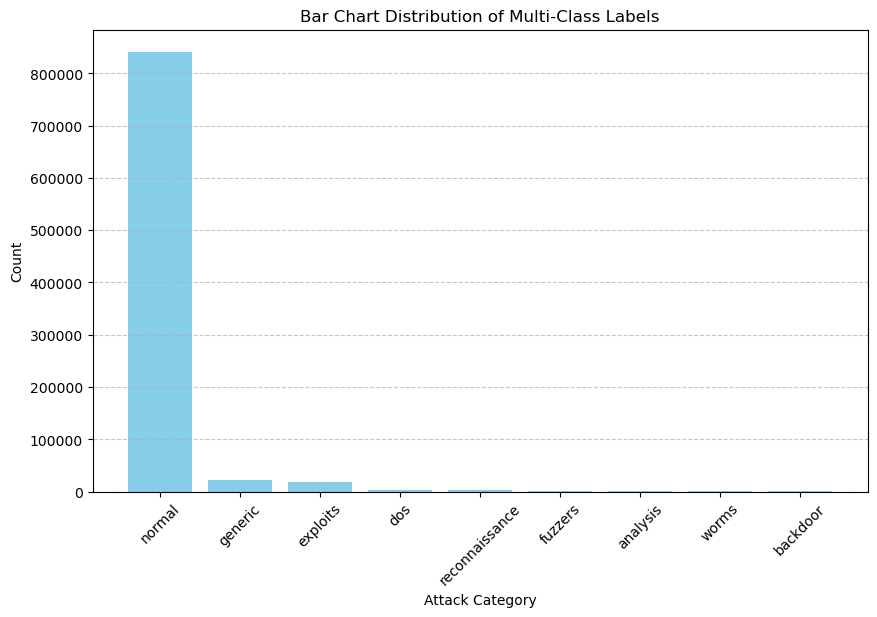

In [213]:
# import matplotlib.pyplot as plt


attack_counts = df_merged.attack_cat.value_counts()

plt.figure(figsize=(10, 6))
plt.bar(attack_counts.index, attack_counts.values, color='skyblue')
plt.xlabel("Attack Category")
plt.ylabel("Count")
plt.title("Bar Chart Distribution of Multi-Class Labels")
plt.xticks(rotation=45)  # Rotate labels if needed
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('plots/Bar_chart_multi.png')
plt.show()


# OneHotEncoding

In [218]:
num_col = df_merged.select_dtypes(include='number').columns


cat_col = df_merged.columns.difference(num_col)
cat_col = cat_col[1:]
cat_col

Index(['proto', 'service', 'state'], dtype='object')

In [220]:
df_cat = df_merged[cat_col].copy()
df_cat.head()

,proto,service,state
1,udp,dns,CON
2,udp,dns,CON
3,udp,dns,CON
5,udp,dns,CON
7,udp,dns,CON


In [222]:
df_cat = pd.get_dummies(df_cat,columns=cat_col)

In [224]:

df_cat.head()
     

,proto_tcp,proto_udp,service_dhcp,service_dns,service_ftp,service_ftp-data,service_http,service_irc,service_pop3,service_radius,service_smtp,service_snmp,service_ssh,service_ssl,state_ACC,state_CLO,state_CON,state_FIN,state_INT,state_REQ,state_RST
1,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
5,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
7,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False


In [226]:
df_merged = pd.concat([df_merged, df_cat],axis=1)

In [228]:
df_merged.drop(columns=cat_col,inplace=True)

In [230]:
df_merged



,srcip,sport,dstip,dsport,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,sload,dload,spkts,dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,sjit,djit,stime,ltime,sintpkt,dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label,proto_tcp,proto_udp,service_dhcp,service_dns,service_ftp,service_ftp-data,service_http,service_irc,service_pop3,service_radius,service_smtp,service_snmp,service_ssh,service_ssl,state_ACC,state_CLO,state_CON,state_FIN,state_INT,state_REQ,state_RST
1,1000734726,1464,2511044103,53,0.001119,146,178,31,29,0,0,521894.531300,6.362824e+05,2,2,0,0,0,0,73,89,0,0,0.000000,0.000000,1421927414,1421927414,0.017000,0.013000,0.000000,0.000000,0.000000,0,0,0.0,0,0,12,8,1,2,2,1,1,normal,0,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2,1000734725,3593,2511044101,53,0.001209,132,164,31,29,0,0,436724.562500,5.425972e+05,2,2,0,0,0,0,66,82,0,0,0.000000,0.000000,1421927414,1421927414,0.043000,0.014000,0.000000,0.000000,0.000000,0,0,0.0,0,0,6,9,1,1,1,1,1,normal,0,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,1000734723,49664,2511044096,53,0.001169,146,178,31,29,0,0,499572.250000,6.090676e+05,2,2,0,0,0,0,73,89,0,0,0.000000,0.000000,1421927414,1421927414,0.005000,0.003000,0.000000,0.000000,0.000000,0,0,0.0,0,0,7,9,1,1,1,1,1,normal,0,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
5,1000734726,2142,2511044100,53,0.001134,132,164,31,29,0,0,465608.468800,5.784832e+05,2,2,0,0,0,0,66,82,0,0,0.000000,0.000000,1421927414,1421927414,0.017000,0.013000,0.000000,0.000000,0.000000,0,0,0.0,0,0,12,7,1,2,2,1,1,normal,0,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
7,1000734725,40726,2511044102,53,0.001126,146,178,31,29,0,0,518650.093800,6.323268e+05,2,2,0,0,0,0,73,89,0,0,0.000000,0.000000,1421927415,1421927415,0.018000,0.013000,0.000000,0.000000,0.000000,0,0,0.0,0,0,6,7,3,1,1,1,1,normal,0,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2540032,1000734724,59563,2511044098,80,1.616038,1626,60216,31,29,2,21,7687.937988,2.913199e+05,22,44,255,255,3559312905,1591848767,74,1369,1,28698,4791.249452,2883.850201,1424262067,1424262069,76.946571,37.571442,0.000579,0.000463,0.000116,0,0,2.0,0,0,1,1,2,2,2,2,2,normal,0,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2540035,1000734721,38606,2511044105,80,0.564998,14106,772406,31,29,2,262,198981.250000,1.091598e+07,262,526,255,255,162243658,163257853,54,1468,1,372266,116.321921,69.874077,1424262068,1424262069,2.123130,1.075171,0.000669,0.000530,0.000139,0,0,2.0,0,0,1,1,4,2,2,2,2,normal,0,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2540038,1000734725,33094,2511044103,43433,0.087306,320,1828,31,29,1,2,24465.671880,1.466108e+05,6,8,255,255,4035116044,222196311,53,229,0,0,1221.136547,30.096029,1424262068,1424262069,17.394400,12.405143,0.000608,0.000468,0.000140,0,0,0.0,0,0,1,2,3,3,1,1,3,normal,0,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
2540041,1000734729,35433,2511044096,80,2.200934,3498,166054,31,29,2,57,12496.513670,5.983751e+05,58,116,255,255,1289728069,3436097151,60,1432,1,

# Data Normalization

In [232]:
 
num_col = list(df_merged.select_dtypes(include='number').columns)
num_col.remove('label')
print(num_col)

['srcip', 'sport', 'dstip', 'dsport', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'sload', 'dload', 'spkts', 'dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'sjit', 'djit', 'stime', 'ltime', 'sintpkt', 'dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm']


In [234]:
# using minmax scaler for normalizing data
minmax_scale = MinMaxScaler(feature_range=(0, 1))
def normalization(df_merged,col):
  for i in col:
    arr = df_merged[i]
    arr = np.array(arr)
    df_merged[i] = minmax_scale.fit_transform(arr.reshape(len(arr),1))
  return df_merged

In [236]:
df_merged = normalization(df_merged.copy(),num_col)

In [238]:
df_merged.head()

,srcip,sport,dstip,dsport,dur,sbytes,dbytes,sttl,dttl,sloss,dloss,sload,dload,spkts,dpkts,swin,dwin,stcpb,dtcpb,smeansz,dmeansz,trans_depth,res_bdy_len,sjit,djit,stime,ltime,sintpkt,dintpkt,tcprtt,synack,ackdat,is_sm_ips_ports,ct_state_ttl,ct_flw_http_mthd,is_ftp_login,ct_ftp_cmd,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label,proto_tcp,proto_udp,service_dhcp,service_dns,service_ftp,service_ftp-data,service_http,service_irc,service_pop3,service_radius,service_smtp,service_snmp,service_ssh,service_ssl,state_ACC,state_CLO,state_CON,state_FIN,state_INT,state_REQ,state_RST
1,0.299907,0.021548,0.845421,0.000489,0.000019,0.000010,0.000012,0.0,0.114173,0.0,0.0,0.000227,0.027216,0.000188,0.000182,0.0,0.0,0.0,0.0,0.048667,0.059333,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,4.037954e-07,3.087850e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.166667,0.106061,0.000000,0.015152,0.015152,0.0,0.0,normal,0,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2,0.299907,0.054061,0.845421,0.000489,0.000020,0.000009,0.000011,0.0,0.114173,0.0,0.0,0.000190,0.023209,0.000188,0.000182,0.0,0.0,0.0,0.0,0.044000,0.054667,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,1.021365e-06,3.325376e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.075758,0.121212,0.000000,0.000000,0.000000,0.0,0.0,normal,0,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,0.299907,0.757628,0.845421,0.000489,0.000019,0.000010,0.000012,0.0,0.114173,0.0,0.0,0.000217,0.026052,0.000188,0.000182,0.0,0.0,0.0,0.0,0.048667,0.059333,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,1.187634e-07,7.125807e-08,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.090909,0.121212,0.000000,0.000000,0.000000,0.0,0.0,normal,0,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
5,0.299907,0.031902,0.845421,0.000489,0.000019,0.000009,0.000011,0.0,0.114173,0.0,0.0,0.000202,0.024744,0.000188,0.000182,0.0,0.0,0.0,0.0,0.044000,0.054667,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,4.037954e-07,3.087850e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.166667,0.090909,0.000000,0.015152,0.015152,0.0,0.0,normal,0,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
7,0.299907,0.621133,0.845421,0.000489,0.000019,0.000010,0.000012,0.0,0.114173,0.0,0.0,0.000225,0.027047,0.000188,0.000182,0.0,0.0,0.0,0.0,0.048667,0.059333,0.0,0.0,0.0,0.0,4.283289e-07,4.283288e-07,4.275481e-07,3.087850e-07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.075758,0.090909,0.030303,0.000000,0.000000,0.0,0.0,normal,0,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False


# Label Encoding

## Binary Labels

In [240]:
# changing attack labels into two categories 'normal' and 'abnormal'
bin_label = pd.DataFrame(df_merged.label.map(lambda x:'normal' if x==0 else 'abnormal'))

In [242]:
bin_data = df_merged.copy()
bin_data['label'] = bin_label

In [244]:
lebal_1 = preprocessing.LabelEncoder()
enc_label = bin_label.apply(lebal_1.fit_transform)
bin_data['label'] = enc_label

In [246]:
lebal_1.classes_

array(['abnormal', 'normal'], dtype=object)

In [248]:

np.save("lebal_1_classes.npy",lebal_1.classes_,allow_pickle=True)

## Multi-class Labels

In [250]:
multi_data = df_merged.copy()
multi_label = pd.DataFrame(multi_data.attack_cat)

In [252]:
multi_data = pd.get_dummies(multi_data,columns=['attack_cat'])

In [254]:
# label encoding (0,1,2,3,4,5,6,7,8) multi-class labels
lebal_2 = preprocessing.LabelEncoder()
enc_label = multi_label.apply(lebal_2.fit_transform)
multi_data['label'] = enc_label

In [256]:
lebal_2.classes_

array(['analysis', 'backdoor', 'dos', 'exploits', 'fuzzers', 'generic',
       'normal', 'reconnaissance', 'worms'], dtype=object)

In [258]:
np.save("lebal_2_classes.npy",lebal_2.classes_,allow_pickle=True)

# Correlation between features of dataset

## Correlation Matrix for Binary Labels

In [260]:
num_col.append('label')
     

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Nakul\\UNSW\\plots\\correlation_matrix_bin.png'

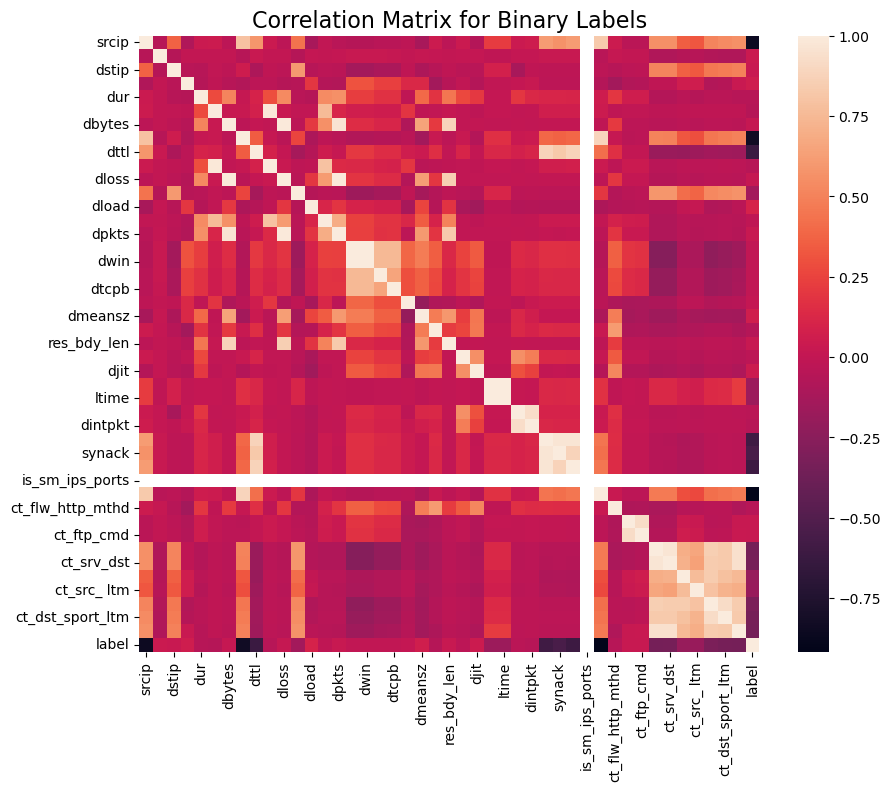

In [262]:
# Correlation Matrix for Binary Labels
plt.figure(figsize=(10,8))
corr_bin = bin_data[num_col].corr()
sns.heatmap(corr_bin,vmax=1.0,annot=False)
plt.title('Correlation Matrix for Binary Labels',fontsize=16)
plt.savefig('plots/correlation_matrix_bin.png')
plt.show()

## Correlation Matrix for Multi-class Labels

In [264]:
num_col = list(multi_data.select_dtypes(include='number').columns)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Nakul\\UNSW\\plots\\correlation_matrix_multi.png'

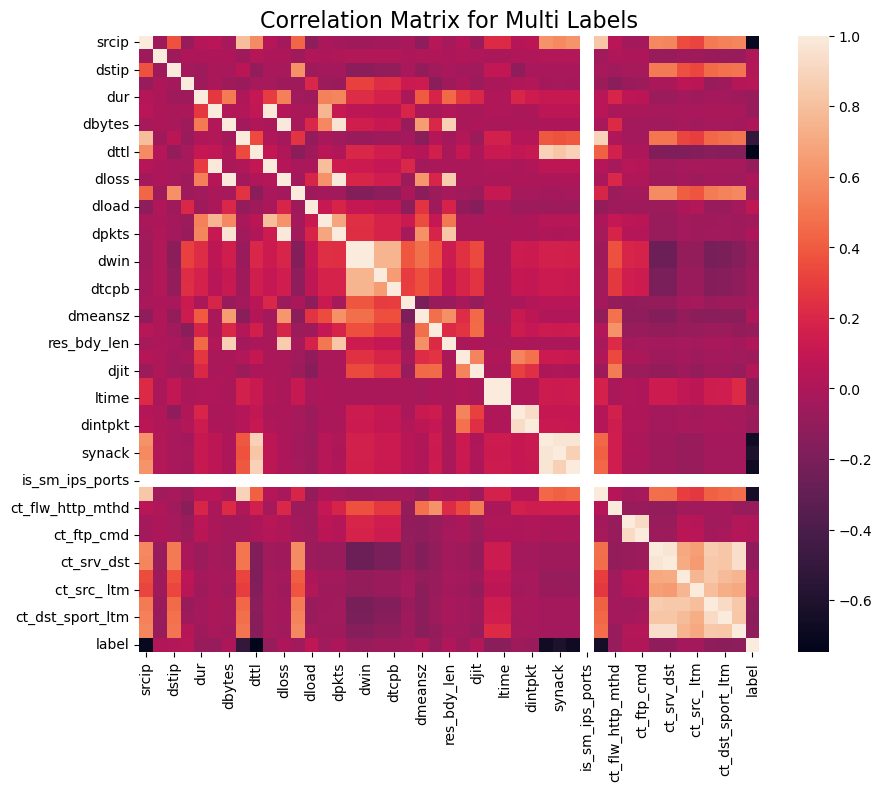

In [266]:

 
plt.figure(figsize=(10,8))
corr_multi = multi_data[num_col].corr()
sns.heatmap(corr_multi,vmax=1.0,annot=False)
plt.title('Correlation Matrix for Multi Labels',fontsize=16)
plt.savefig('plots/correlation_matrix_multi.png')
plt.show()
     

# FEATURE SELECTION

## Binary Labels

In [268]:
# finding the attributes which have more than 0.3 correlation with encoded attack label attribute 
corr_ybin = abs(corr_bin['label'])
highest_corr_bin = corr_ybin[corr_ybin >0.3]
highest_corr_bin.sort_values(ascending=True)

ct_src_dport_ltm    0.313785
ct_dst_sport_ltm    0.334619
ct_srv_dst          0.338530
ct_srv_src          0.342496
ct_dst_src_ltm      0.343033
synack              0.545613
tcprtt              0.593247
ackdat              0.603352
dttl                0.622372
sttl                0.830428
srcip               0.855432
ct_state_ttl        0.916445
label               1.000000
Name: label, dtype: float64

In [270]:

# selecting attributes found by using pearson correlation coefficient
bin_cols = highest_corr_bin.index
bin_cols
     

Index(['srcip', 'sttl', 'dttl', 'tcprtt', 'synack', 'ackdat', 'ct_state_ttl',
       'ct_srv_src', 'ct_srv_dst', 'ct_src_dport_ltm', 'ct_dst_sport_ltm',
       'ct_dst_src_ltm', 'label'],
      dtype='object')

In [272]:
# Binary labelled Dataset
bin_data = bin_data[bin_cols].copy()
bin_data

,srcip,sttl,dttl,tcprtt,synack,ackdat,ct_state_ttl,ct_srv_src,ct_srv_dst,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,label
1,0.299907,0.000000,0.114173,0.000000,0.000000,0.000000,0.0,0.166667,0.106061,0.015152,0.000000,0.000000,1
2,0.299907,0.000000,0.114173,0.000000,0.000000,0.000000,0.0,0.075758,0.121212,0.000000,0.000000,0.000000,1
3,0.299907,0.000000,0.114173,0.000000,0.000000,0.000000,0.0,0.090909,0.121212,0.000000,0.000000,0.000000,1
5,0.299907,0.000000,0.114173,0.000000,0.000000,0.000000,0.0,0.166667,0.090909,0.015152,0.000000,0.000000,1
7,0.299907,0.000000,0.114173,0.000000,0.000000,0.000000,0.0,0.075758,0.090909,0.000000,0.000000,0.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2540032,0.299907,0.000000,0.114173,0.000388,0.000889,0.000081,0.0,0.000000,0.000000,0.015152,0.027027,0.015152,1
2540035,0.299907,0.000000,0.114173,0.000449,0.001018,0.000098,0.0,0.000000,0.000000,0.015152,0.027027,0.015152,1
2540038,0.299907,0.000000,0.114173,0.000408,0.000899,0.000098,0.0,0.000000,0.015152,0.000000,0.000000,0.030303,1
2540041,0.299907,0.000000,0.114173,0.000456,0.001039,0.000098,0.0,0.000000,0.000000,0.015152,0.027027,0.015152,1


# Saving Dataset ('binary and multi class data')

In [274]:
import os
os.makedirs('datasets', exist_ok=True)
bin_data.to_csv('./datasets/bin_data.csv')

In [276]:
# finding the attributes which have more than 0.3 correlation with encoded attack label attribute 
corr_ymulti = abs(corr_multi['label'])
highest_corr_multi = corr_ymulti[corr_ymulti >0.3]
highest_corr_multi.sort_values(ascending=True)
     

sttl            0.508057
synack          0.614336
ct_state_ttl    0.647553
tcprtt          0.666549
ackdat          0.676578
srcip           0.705827
dttl            0.745803
label           1.000000
Name: label, dtype: float64

In [278]:
multi_cols = highest_corr_multi.index
multi_cols

Index(['srcip', 'sttl', 'dttl', 'tcprtt', 'synack', 'ackdat', 'ct_state_ttl',
       'label'],
      dtype='object')

In [280]:
multi_data = multi_data[multi_cols].copy()

In [282]:
multi_data.to_csv('./datasets/multi_data.csv')